# Training Deep Neural Network on a GPU with Pytorch

## Preparing Data

In [3]:
import torch
import numpy as np
import torchvision
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader

In [4]:
dataset = MNIST(root="data/",
                download=True,
                transform=ToTensor())

In [5]:
dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
img, label = dataset[0]
img.shape, label

(torch.Size([1, 28, 28]), 5)

<function matplotlib.pyplot.show(close=None, block=None)>

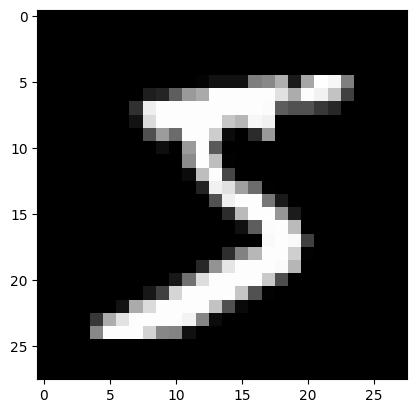

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(img[0], cmap="gray")
plt.show

In [10]:
img[0, 10:15, 10:15]

tensor([[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
        [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
        [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
        [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
        [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]])

In [16]:
def split_indices(n, val_pct):
    n_val = int(n*val_pct)
    indx = np.random.permutation(n)
    return indx[n_val:], indx[:n_val]

In [18]:
train_indices, val_indices = split_indices(len(dataset), val_pct=0.2)

print(len(train_indices), len(val_indices))
print("Sample val indices: ", val_indices[:20])

48000 12000
Sample val indices:  [33730 20024 26997 11490 27160  9557 22695 46031  4277 36214 57816 29693
 34733 59379  4334   509 57451 56539 54864 13695]


In [20]:
batch_size = 100

#Training sampler and data loader
train_sampler = SubsetRandomSampler(train_indices)
train_dl = DataLoader(dataset,
                      batch_size,
                      sampler=train_sampler)

#Validation sampler and data loader
val_sampler = SubsetRandomSampler(val_indices)
val_dl = DataLoader(dataset,
                      batch_size,
                      sampler=train_sampler)

## Model

In [25]:
import torch.nn.functional as F
import torch.nn as nn

In [27]:
class MnistModel(nn.Module):
    def __init__(self, in_size, hidden_size, out_size):
        super().__init__()
        #hidden layer
        self.linear1 = nn.Linear(in_size, hidden_size)
        #output layer
        self.linear2 = nn.Linear(hidden_size, out_size)

    def forward(self, xb):
        #Flatten the image tensors
        xb = x.view(xb.size(0), -1)
        #Get Intermediate Output using Hidden Layer
        out = self.linear1(xb)
        #Apply the activation function
        out = F.relu(out)
        #Get the predcition using Ouput Layer
        out = self.linear2(out)
        return out

In [29]:
input_size = 784
num_classes = 10

model = MnistModel(input_size, hidden_size=32, out_size=num_classes)